In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
import pandas as pd
df = pd.read_excel("D:\summer\ML\salary.xlsx")
print(df.head())

<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Mr.Laptop point\AppData\Local\Temp\ipykernel_15352\3192914141.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_excel("D:\summer\ML\salary.xlsx")


    Age   Estimatedsalary  Purchased
0     40           150000          1
1     50           170000          1
2     35           125000          0
3     27            80000          1
4     23            65000          0


In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(df.drop('Purchased',axis=1),
                                                 df['Purchased'],
                                                 test_size=0.3,
                                                 random_state=0
                                                 )
X_train.shape , X_test.shape

((4, 2), (2, 2))

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)
scaler.mean_

array([3.5000e+01, 1.1625e+05])

In [5]:
X_train

,Age,Estimatedsalary
1,50,170000
3,27,80000
0,40,150000
4,23,65000


In [7]:
import numpy as np
x_test_scaled = pd.DataFrame(x_test_scaled,columns=X_test.columns)
x_train_scaled = pd.DataFrame(x_train_scaled,columns=X_train.columns)
np.round(X_train.describe(),1)

,Age,Estimatedsalary
count,4.0,4.0
mean,35.0,116250.0
std,12.4,51538.8
min,23.0,65000.0
25%,26.0,76250.0
50%,33.5,115000.0
75%,42.5,155000.0
max,50.0,170000.0


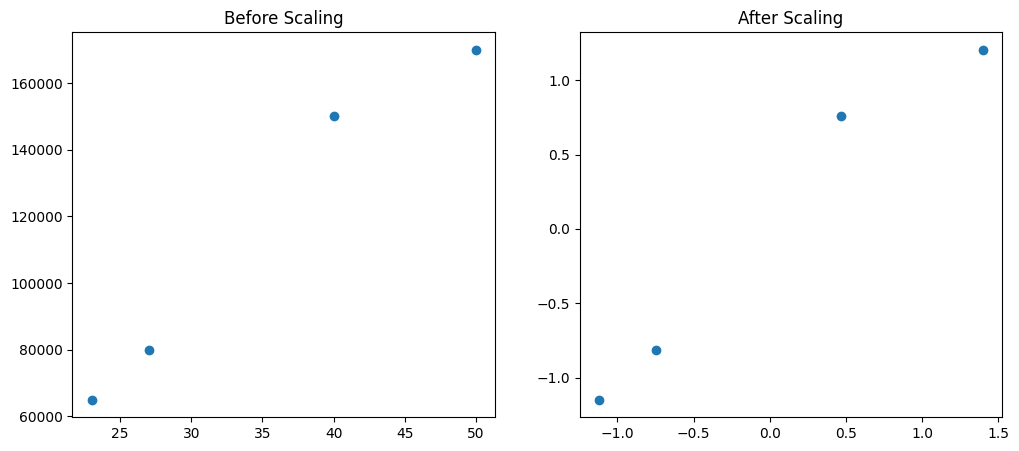

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
fig , (ax1,ax2) = plt.subplots(ncols = 2, figsize=(12,5))
ax1.scatter(X_train[' Age '],X_train['Estimatedsalary'])
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled[' Age '],x_train_scaled['Estimatedsalary'])
ax2.set_title('After Scaling')
plt.show()

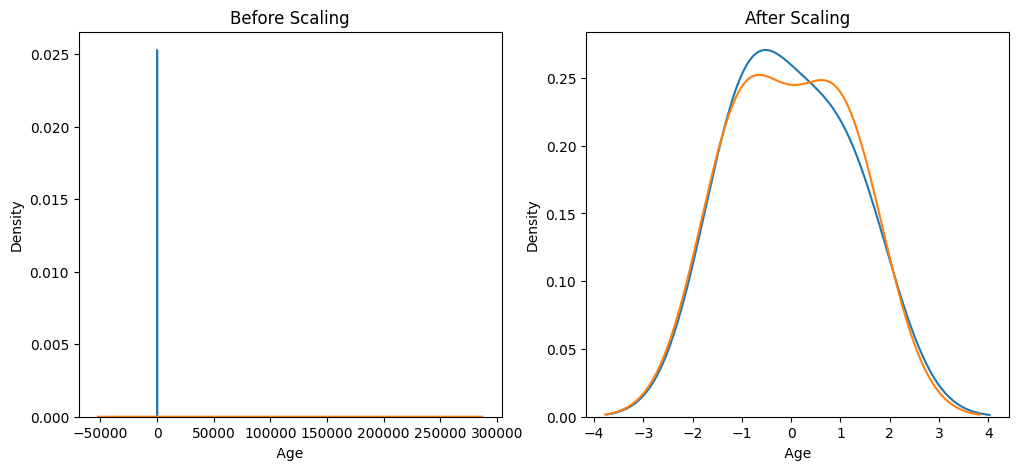

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
fig , (ax1,ax2) = plt.subplots(ncols = 2, figsize=(12,5))
ax1.set_title('Before Scaling')
sns.kdeplot(X_train[' Age '],ax=ax1)
sns.kdeplot(X_train['Estimatedsalary'],ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled[' Age '],ax=ax2)
sns.kdeplot(x_train_scaled['Estimatedsalary'],ax=ax2)
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_scaled = LogisticRegression()
lr.fit(X_train,Y_train)
lr_scaled.fit(x_train_scaled,Y_train)
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)


In [15]:
from sklearn.metrics import accuracy_score
print("Actual",accuracy_score(Y_test,y_pred))
print("scaled",accuracy_score(Y_test,y_pred_scaled))

Actual 0.5
scaled 0.5
